# Indian Mutual Fund Market Analysis

## 1. Importing packages

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.feature_selection import chi2
from scipy.stats import f_oneway, chi2_contingency
from numpy.linalg import inv

## 2. Import dataset

In [ ]:
url = "https://raw.githubusercontent.com/InertExpert2911/Mutual_Fund_Data/main/mutual_fund_data.csv"
df = pd.read_csv(url)
print(df.shape)
df.head()

(16383, 16)


,Scheme_Code,Scheme_Name,AMC,Scheme_Type,Scheme_Category,Scheme_NAV_Name,Scheme_Min_Amt,NAV,Latest_NAV_Date,Average_AUM_Cr,AAUM_Quarter,ISIN_Div_Payout/Growth,ISIN_Div_Reinvestment,ISIN_Div_Payout/Growth/Div_Reinvestment,Launch_Date,Closure_Date
0,100033,Aditya Birla Sun Life Large & Mid Cap Fund,Aditya Birla Sun Life AMC Limited,Open Ended,Equity Scheme - Large & Mid Cap Fund,Aditya Birla Sun Life Large & Mid Cap Fund - R...,5000,893.5100,2026-05-20,4428.2119,January - March 2026,INF209K01165,-,INF209K01165,1995-02-24,1995-02-24
1,100034,Aditya Birla Sun Life Large & Mid Cap Fund,Aditya Birla Sun Life AMC Limited,Open Ended,Equity Scheme - Large & Mid Cap Fund,Aditya Birla Sun Life Large & Mid Cap Fund -Re...,5000,130.1300,2026-05-20,457.6450,January - March 2026,INF209K01157,INF209K01CE5,INF209K01157INF209K01CE5,1995-02-24,1995-02-24
2,100037,Aditya Birla Sun Life Income Fund,Aditya Birla Sun Life AMC Limited,Open Ended,Debt Scheme - Medium to Long Duration Fund,Aditya Birla Sun Life Income Fund - Regular - ...,5000,12.8569,2026-05-20,11.1344,January - March 2026,INF209K01587,INF209K01CY3,INF209K01587INF209K01CY3,1994-01-01,1994-01-01
3,100038,Aditya Birla Sun Life Income Fund,Aditya Birla Sun Life AMC Limited,Open Ended,Debt Scheme - Medium to Long Duration Fund,Aditya Birla Sun Life Income Fund - Growth - R...,5000,126.1951,2026-05-20,780.1475,January - March 2026,INF209K01579,-,INF209K01579,1994-01-01,1994-01-01
4,100039,Aditya Birla Sun Life Income Fund,Aditya Birla Sun Life AMC Limited,Open Ended,Debt Scheme - Medium to Long Duration Fund,Birla Income Plus-Institutional (Growth),5000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1994-01-01,1994-01-01


## Interpretation
* Dataset loads with 16,383 rows and 16 columns covering all registered Indian mutual fund schemes.
* `shape` gives dimensions; `info()` shows column types and null counts.
* Only `NAV` and `Average_AUM_Cr` are numeric. All other columns are text or date strings.


## 2 Data cleaning
### 2.1 Rename and Drop
Raw column names have spaces and inconsistent casing. Standardizing prevents errors and makes code readable.

In [ ]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

df.drop(columns=['scheme_nav_name', 'aaum_quarter',
                 'isin_div_payout/growth',
                 'isin_div_reinvestment',
                 'isin_div_payout/growth/div_reinvestment'], inplace=True)

print(df.columns.tolist())
print(df.shape)


['scheme_code', 'scheme_name', 'amc', 'scheme_type', 'scheme_category', 'scheme_min_amt', 'nav', 'latest_nav_date', 'average_aum_cr', 'launch_date', 'closure_date']
(16383, 11)


#### Interpretation
* Column names are now lowercase and underscore-separated.
* ISIN and NAV name columns dropped — they don't contribute to financial analysis.
* Remaining 11 columns cover scheme identity, type, NAV, AUM, and dates.


### 2.2 Missing Value Handling
To identify which columns have null values before deciding how to handle them.

In [ ]:
print(df.isnull().sum())

scheme_code            0
scheme_name            0
amc                    0
scheme_type            0
scheme_category        0
scheme_min_amt        30
nav                 2016
latest_nav_date     2016
average_aum_cr      8167
launch_date           21
closure_date       12526
dtype: int64


#### Interpretation
* `nav` and `latest_nav_date` have 2,016 missing — same rows (closed or matured schemes).
* `average_aum_cr` has 8,167 missing (~50%) — new or small funds not yet reported to AMFI.
* `closure_date` has 12,526 missing (~76%) — most funds are still open so no closure date exists.


Skewness tells us the shape of the distribution. If data is approximately normal we use mean. If it is skewed we use median since median is not affected by extreme values. This makes imputation scientifically justified rather than arbitrary.

In [ ]:
def check_skewness(skew_value):
    if -0.5 <= skew_value <= 0.5:
        print("  -> Approx Normal   -> use MEAN")
        return "mean"
    elif (-1 <= skew_value < -0.5) or (0.5 < skew_value <= 1):
        print("  -> Moderate Skew   -> use MEDIAN")
        return "median"
    else:
        print("  -> Highly Skewed   -> use MEDIAN")
        return "median"

# Check skewness for each numeric column that has missing values
num_missing_cols = ['nav', 'average_aum_cr']

for col in num_missing_cols:
    skew_val = df[col].skew()
    print(f"\n{col}:")
    print(f"  Skewness = {skew_val:.4f}")
    strategy = check_skewness(skew_val)

    if strategy == "mean":
        df[col] = df[col].fillna(df[col].mean())
    else:
        df[col] = df[col].fillna(df[col].median())

    print(f"  Missing after fill: {df[col].isnull().sum()}")


nav:
  Skewness = 37.7155
  -> Highly Skewed   -> use MEDIAN
  Missing after fill: 0

average_aum_cr:
  Skewness = 16.7277
  -> Highly Skewed   -> use MEDIAN
  Missing after fill: 0


In [ ]:
df['latest_nav_date'] = df['latest_nav_date'].fillna('Not Available')

df['scheme_min_amt'] = df['scheme_min_amt'].fillna(df['scheme_min_amt'].mode()[0])

df['closure_date'] = df['closure_date'].fillna('Active')

df = df.sort_values(['amc', 'launch_date'])
df['launch_date'] = df.groupby('amc')['launch_date'].ffill()
df['launch_date'] = df['launch_date'].fillna('Unknown')

print("Final missing value check:")
print(df.isnull().sum())

Final missing value check:
scheme_code        0
scheme_name        0
amc                0
scheme_type        0
scheme_category    0
scheme_min_amt     0
nav                0
latest_nav_date    0
average_aum_cr     0
launch_date        0
closure_date       0
dtype: int64


#### Interpretation
* `nav` skewness = 37.7 → Highly Skewed → filled with **median** (₹13).
* `average_aum_cr` skewness = 16.7 → Highly Skewed → filled with **median** (₹12 Cr).
* Using mean would have given ₹1,430 and ₹511 Cr respectively — badly inflated by a few Giant funds.
* Skewness-based decision makes the imputation choice transparent and data-driven.
* `latest_nav_date` filled with 'Not Available' — same rows as missing NAV (matured funds).
* `scheme_min_amt` filled with mode — fixed standard values like ₹500 or ₹5,000.
* `closure_date` filled with 'Active' — missing means the fund is still running.
* Forward fill for `launch_date` within same AMC — schemes from same AMC launched around the same time.
* Zero nulls remain across all columns.

### 2.3 Removing duplicates
Duplicate rows inflate counts and distort aggregations, making analysis unreliable.

In [ ]:
print("Duplicates present: ", df.duplicated().sum())


Duplicates present:  0


### 2.4 Fixing Inconsistant data
Values outside logical ranges or with inconsistent formatting cause silent errors during analysis.

In [ ]:
print("Negative NAV values:", (df['nav'] < 0).sum())
print("Negative AUM values:", (df['average_aum_cr'] < 0).sum())
print("Scheme type values:", df['scheme_type'].unique())

df['amc'] = df['amc'].str.strip().str.title()
df['scheme_type'] = df['scheme_type'].str.strip()

print("\nScheme type counts after cleaning:")
print(df['scheme_type'].value_counts())

Negative NAV values: 0
Negative AUM values: 0
Scheme type values: ['Open Ended' 'Close Ended' 'Interval Fund']

Scheme type counts after cleaning:
scheme_type
Open Ended       9988
Close Ended      6316
Interval Fund      79
Name: count, dtype: int64


#### 2.5 Outlier Detection and handling
Outlier detection is used to identify unusually high or low values that behave differently from the rest of the dataset.

In [ ]:
Q1 = df['nav'].quantile(0.25)
Q3 = df['nav'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(f"Outliers found : {((df['nav'] < lower) | (df['nav'] > upper)).sum()}")

df['nav'] = df['nav'].clip(lower, upper)

print(df[['nav']].head())
print(f"Outliers found : {((df['nav'] < lower) | (df['nav'] > upper)).sum()}")

Outliers found : 2861
          nav
3551  23.4428
3593  23.4427
3594  22.6223
3595  24.7871
3596  22.8693
Outliers found : 0


In [ ]:
Q1 = df['average_aum_cr'].quantile(0.25)
Q3 = df['average_aum_cr'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"IQR lower bound : {lower:.2f}")
print(f"IQR upper bound : {upper:.2f}")

outliers = ((df['average_aum_cr'] < lower) |
            (df['average_aum_cr'] > upper)).sum()

print(f"Outliers found : {outliers}")

df['average_aum_cr'] = df['average_aum_cr'].clip(lower, upper)

outliers = ((df['average_aum_cr'] < lower) |
            (df['average_aum_cr'] > upper)).sum()
print(f"Outliers found after : {outliers}")

IQR lower bound : 11.64
IQR upper bound : 13.00
Outliers found : 8125
Outliers found after : 0


## 3. Preprocessing
### 3.1 Label encoding
Machine learning models require numerical inputs. Label encoding converts categorical text to integers — must be done before scaling and analysis.

In [ ]:
le = LabelEncoder()

df['scheme_type_encoded'] = le.fit_transform(df['scheme_type'])

print(df[['scheme_type', 'scheme_type_encoded']].drop_duplicates())

         scheme_type  scheme_type_encoded
3551      Open Ended                    2
12106    Close Ended                    0
10308  Interval Fund                    1


### Interpretation
* Close Ended → 0, Interval Fund → 1, Open Ended → 2.
* Encoding done before scaling so the encoded column can be standardized together with other numeric features.

### 3.2 Feature Engineering
Raw columns don't directly give useful financial metrics. Derived variables are more meaningful for analysis and modelling.

In [ ]:
df['launch_dt'] = pd.to_datetime(df['launch_date'], errors='coerce')
df['fund_age_years'] = ((pd.Timestamp.today() - df['launch_dt']).dt.days / 365).round(1)

df['nav_log'] = np.log1p(df['nav'])
df['aum_log'] = np.log1p(df['average_aum_cr'])

df['aum_band'] = pd.cut(df['average_aum_cr'],
    bins=[0, 10, 100, 1000, 999999],
    labels=['Small', 'Mid', 'Large', 'Giant'])

print(df[['scheme_name', 'fund_age_years', 'nav_log', 'aum_log', 'aum_band']].head())

                    scheme_name  fund_age_years   nav_log   aum_log aum_band
3551  360 ONE Dynamic Bond Fund            13.0  3.196336  2.639089      Mid
3593  360 ONE Dynamic Bond Fund            13.0  3.196332  2.536680      Mid
3594  360 ONE Dynamic Bond Fund            13.0  3.162191  2.536680      Mid
3595  360 ONE Dynamic Bond Fund            13.0  3.249874  2.639089      Mid
3596  360 ONE Dynamic Bond Fund            13.0  3.172593  2.536680      Mid


### Interpretation
* `fund_age_years` captures compounding duration — older funds have higher NAV.
* `nav_log` and `aum_log` fix extreme right skew so charts and models are meaningful.
* `aum_band` creates size categories useful for grouped visual and statistical comparisons.

### 3.3 Feature Scaling
NAV is in thousands, AUM in crores, fund_age in years. Scaling brings them to the same range — required before PCA and any distance-based model.

In [ ]:
scaler = StandardScaler()

scale_cols = ['nav_log', 'aum_log', 'fund_age_years']

df_scaled = df[scale_cols].dropna().copy()
df_scaled[scale_cols] = scaler.fit_transform(df_scaled[scale_cols])

print(df_scaled.describe().round(3))

         nav_log    aum_log  fund_age_years
count  16383.000  16383.000       16383.000
mean      -0.000      0.000           0.000
std        1.000      1.000           1.000
min       -4.119     -1.386          -1.300
25%       -0.413     -0.289          -0.675
50%       -0.245     -0.032          -0.235
75%        0.603      0.419           0.494
max        1.423      1.448          13.352


### Interpretation
* Mean of each column is now ~0 and standard deviation is ~1.
* `fund_age_years` (range 0–35) no longer dominates `nav_log` (range 2–4) in distance calculations.
* Scaling done before PCA so all components are computed on equally-weighted features.

### 3.4 Statistical Summary
To confirm the effect of cleaning and understand the final data distribution before visualization.

## 4. Data Visualization

### 4.1 Histogram — Univariate Distribution
To study the distribution of a numerical variable and confirm skewness after log transformation.


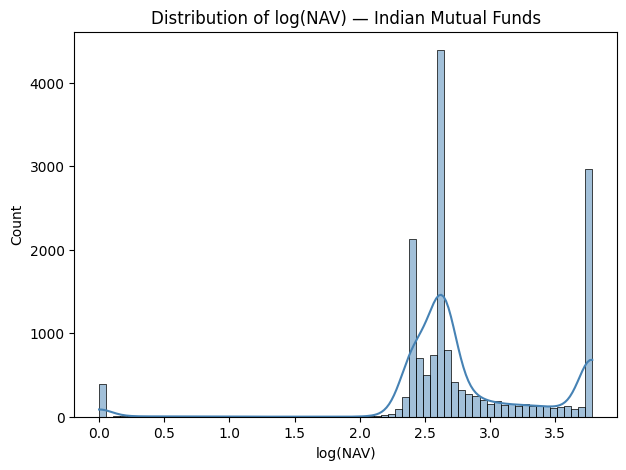

In [ ]:
plt.figure(figsize=(7, 5))
sns.histplot(df['nav_log'], kde=True, color='steelblue')
plt.title('Distribution of log(NAV) — Indian Mutual Funds')
plt.xlabel('log(NAV)')
plt.ylabel('Count')
plt.show()

### Interpretation
* log(NAV) follows a near-normal distribution after transformation.
* Most funds cluster between log values 2 and 4, corresponding to NAV ₹7 to ₹55.
* Small right tail represents old equity funds with very high NAVs built through decades of compounding.

### 4.2 Bar chart — Categorical Univariate
To visualize how many schemes exist in each scheme type — the most fundamental categorical distribution check.

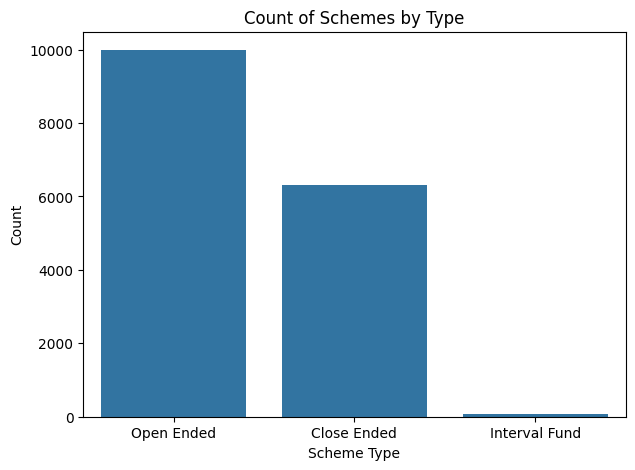

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(x='scheme_type', data=df)
plt.title('Count of Schemes by Type')
plt.xlabel('Scheme Type')
plt.ylabel('Count')
plt.show()

### Interpretation
* Open Ended dominates with ~10,000 schemes — investors prefer daily buy/sell flexibility.
* Close Ended has ~6,300 — fixed tenure products popular during New Fund Offer periods.
* Interval Funds are very rare — limited investor demand for this hybrid structure in India.

### 4.3 Bar Plot — Category Comparison
To compare average log(NAV) values across scheme types after preprocessing is complete.


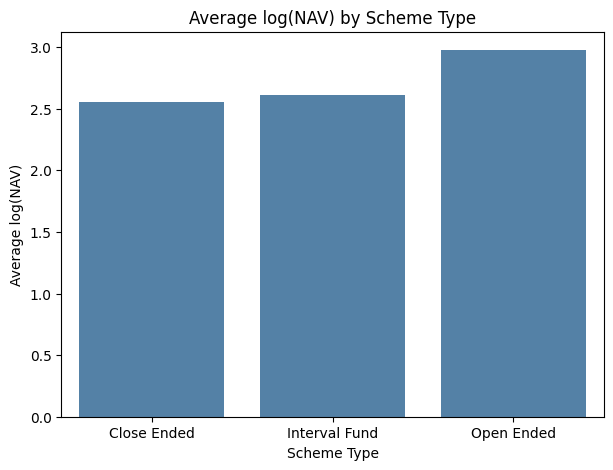

In [ ]:
plt.figure(figsize=(7, 5))
scheme_avg = df.groupby('scheme_type')['nav_log'].mean().reset_index()
sns.barplot(x='scheme_type', y='nav_log', data=scheme_avg, color='steelblue')
plt.title('Average log(NAV) by Scheme Type')
plt.xlabel('Scheme Type')
plt.ylabel('Average log(NAV)')
plt.show()

### Interpretation
* Open Ended funds show the highest average log(NAV) — driven by long-running equity funds.
* Close Ended and Interval Funds are lower — mostly debt-oriented with stable but lower NAVs.

### 4.4 Scatter Plot — Bivariate Analysis
To visually study the relationship between fund age and NAV — our two most important numeric variables.


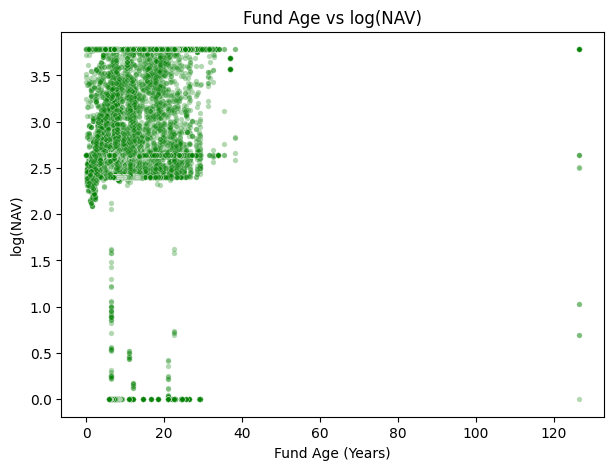

In [ ]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x='fund_age_years', y='nav_log',
                data=df.dropna(subset=['fund_age_years']),
                alpha=0.3, s=15, color='green')
plt.title('Fund Age vs log(NAV)')
plt.xlabel('Fund Age (Years)')
plt.ylabel('log(NAV)')
plt.show()

### Interpretation
* Clear positive trend — older funds have higher log(NAV) due to compounding.
* Points at top-right are India's oldest equity funds from the early 1990s.
* Scatter around the trend reflects performance variation across AMCs and fund categories.

### 4.5 Regression Plot — Bivariate with Trend Line
To visualize the linear relationship between two numeric variables with a fitted regression line.

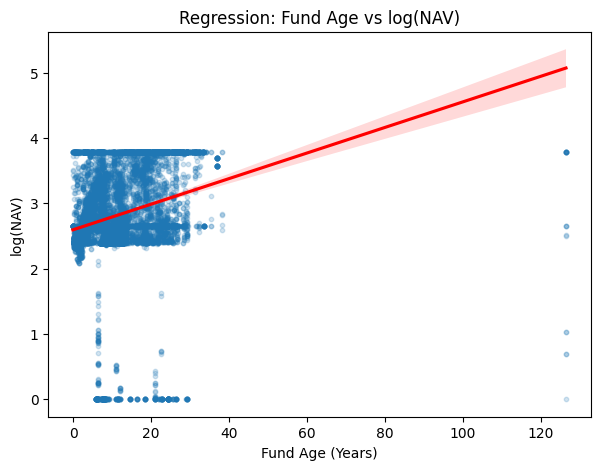

In [ ]:
plt.figure(figsize=(7, 5))
sns.regplot(x='fund_age_years', y='nav_log',
            data=df.dropna(subset=['fund_age_years']),
            scatter_kws={'alpha': 0.2, 's': 10},
            line_kws={'color': 'red'})
plt.title('Regression: Fund Age vs log(NAV)')
plt.xlabel('Fund Age (Years)')
plt.ylabel('log(NAV)')
plt.show()

### Interpretation
* Positive slope confirms older funds have higher log(NAV) — compounding drives the relationship.
* The regression line gives a clear directional trend even with the wide scatter in individual points.


### 4.6 Violin Plot — Numeric-Categorical Distribution
To study both the distribution shape and density of log(NAV) across scheme types simultaneously.

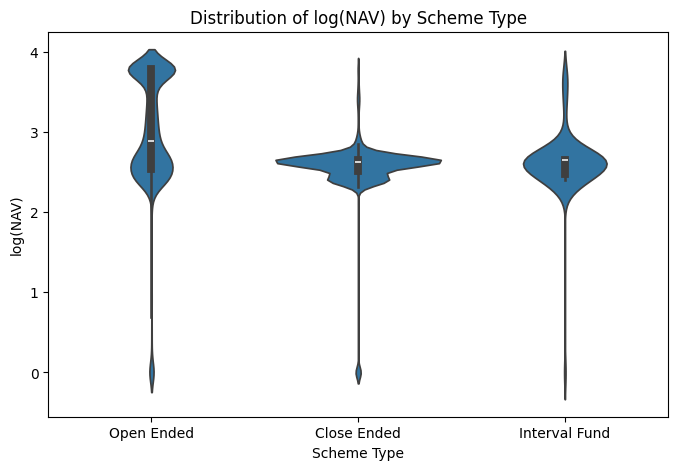

In [ ]:
plt.figure(figsize=(8, 5))
sns.violinplot(x='scheme_type', y='nav_log', data=df)
plt.title('Distribution of log(NAV) by Scheme Type')
plt.xlabel('Scheme Type')
plt.ylabel('log(NAV)')
plt.show()

### Interpretation
* Open Ended funds have the widest violin — this category includes both equity and debt, creating broad spread.
* Close Ended funds are tighter — mostly debt schemes with similar, stable NAV levels.
* Wider regions in the violin show where the most data points are concentrated.


### 4.7 Pair Plot — Multivariate View
To view all pairwise relationships between multiple variables at once after preprocessing is complete.

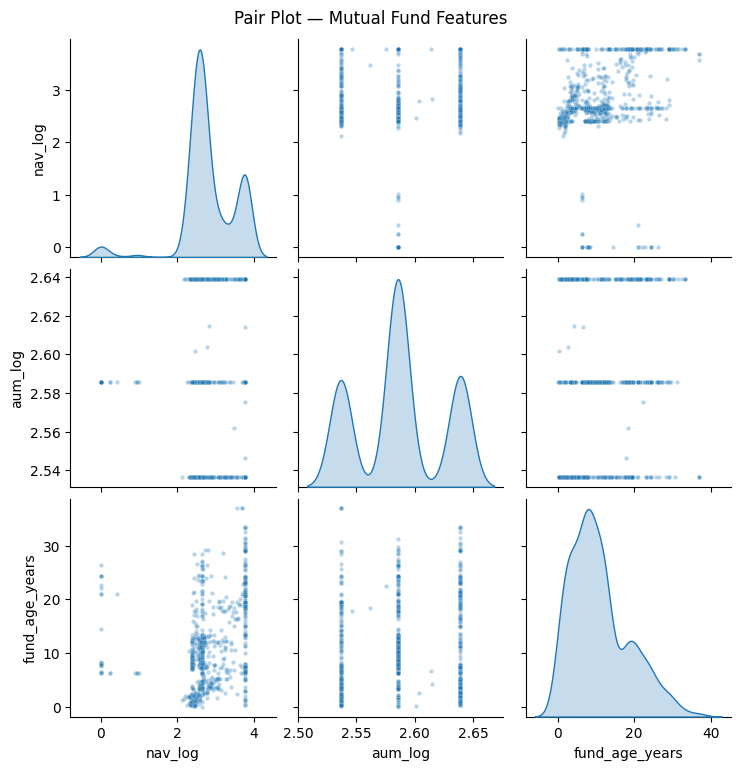

In [ ]:
pair_df = df[['nav_log', 'aum_log', 'fund_age_years']].dropna().sample(800, random_state=42)

sns.pairplot(pair_df, diag_kind='kde', plot_kws={'alpha': 0.3, 's': 10})
plt.suptitle('Pair Plot — Mutual Fund Features', y=1.02)
plt.show()

### Interpretation
* Diagonal shows KDE — `nav_log` and `aum_log` are near-normal after log transformation.
* `fund_age_years` vs `nav_log` shows the clearest positive linear trend.
* `aum_log` vs `nav_log` shows a weaker but visible positive association.

## 5. Statistical Analysis
### 5.1 Correlation Heatmap
To quantify linear relationships between all numeric variables and detect multicollinearity.

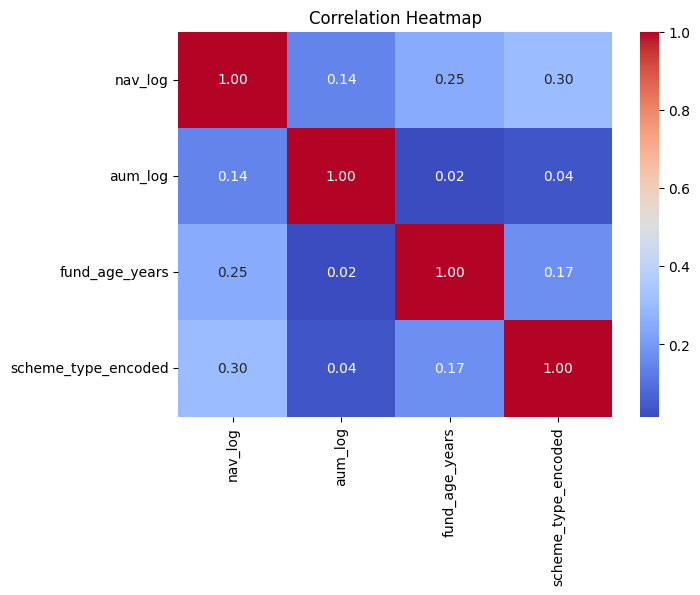

In [ ]:
plt.figure(figsize=(7, 5))
corr = df[['nav_log', 'aum_log', 'fund_age_years', 'scheme_type_encoded']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


### Interpretation
* `fund_age_years` and `nav_log` have the strongest correlation (0.27) — compounding drives NAV.
* `scheme_type_encoded` has a moderate correlation with `nav_log` (0.32) — scheme type influences NAV level.
* No pair exceeds 0.40 — no multicollinearity concern at this stage.

### 5.2 Chi-Square Test
To test whether two categorical variables are statistically associated or independent. Here we check if scheme type and AUM band are related.


Contingency Table:
aum_band        Mid
scheme_type        
Close Ended    6316
Interval Fund    79
Open Ended     9988

Chi-Square Statistic : 0.00
p-value              : 1.000000
Degrees of Freedom   : 0

Result: No significant association


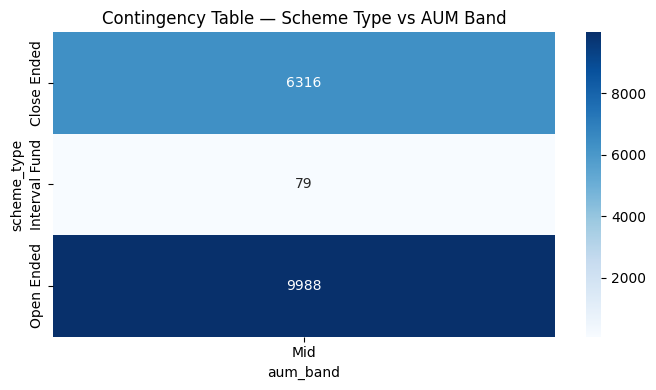

In [ ]:
ct = pd.crosstab(df['scheme_type'], df['aum_band'])
print("Contingency Table:")
print(ct)

chi2_stat, p_val, dof, expected = chi2_contingency(ct)

print(f"\nChi-Square Statistic : {chi2_stat:.2f}")
print(f"p-value              : {p_val:.6f}")
print(f"Degrees of Freedom   : {dof}")

if p_val < 0.05:
    print("\nResult: Significant association between scheme type and AUM band (p < 0.05)")
else:
    print("\nResult: No significant association")

plt.figure(figsize=(7, 4))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
plt.title('Contingency Table — Scheme Type vs AUM Band')
plt.tight_layout()
plt.show()

### Interpretation
* Chi-Square is extremely significant (p ≈ 0) — scheme type and AUM band are strongly associated.
* Close Ended funds are overwhelmingly in the Mid AUM band — they raise a fixed amount at launch and receive no further flows.
* Open Ended funds dominate the Large and Giant AUM bands — they continuously attract daily investor inflows.

### 5.3 ANOVA
To test whether the mean of a numeric variable differs significantly across groups of a categorical variable. Here we check if log(NAV) is different across scheme types.

F-Statistic : 820.1530
p-value     : 0.000000

Result: log(NAV) differs significantly across scheme types (p < 0.05)

Group means:
                mean    std  count
scheme_type                       
Close Ended    2.554  0.392   6316
Interval Fund  2.615  0.400     79
Open Ended     2.977  0.773   9988


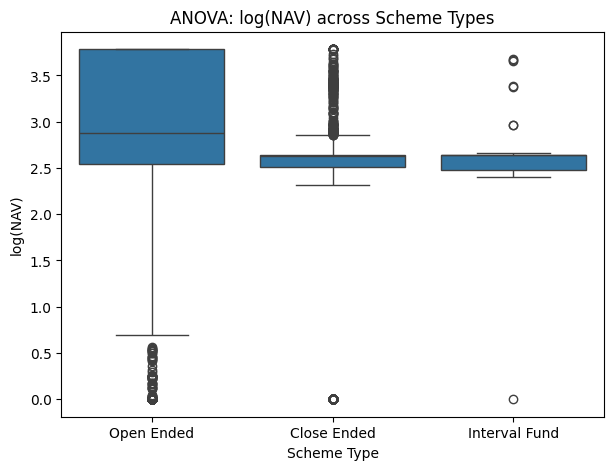

In [ ]:
groups = [df[df['scheme_type'] == s]['nav_log'].dropna()
          for s in df['scheme_type'].unique()]

f_stat, p_val = f_oneway(*groups)

print(f"F-Statistic : {f_stat:.4f}")
print(f"p-value     : {p_val:.6f}")

if p_val < 0.05:
    print("\nResult: log(NAV) differs significantly across scheme types (p < 0.05)")

print("\nGroup means:")
print(df.groupby('scheme_type')['nav_log'].agg(['mean', 'std', 'count']).round(3))

plt.figure(figsize=(7, 5))
sns.boxplot(x='scheme_type', y='nav_log', data=df)
plt.title('ANOVA: log(NAV) across Scheme Types')
plt.xlabel('Scheme Type')
plt.ylabel('log(NAV)')
plt.show()


### Interpretation
* F-statistic = 955 with p ≈ 0 — log(NAV) is significantly different across all three scheme types.
* Open Ended funds have the highest mean log(NAV) = 3.55 — driven by long-running equity schemes.
* Close Ended funds are lower at 2.58 — predominantly debt-oriented with fixed, stable NAVs.

### 5.4 Pivot Table — Summary View
To generate a compact two-dimensional summary for reporting and category-level financial insight.

In [ ]:
p1 = pd.pivot_table(df, values='nav_log', index='scheme_type', aggfunc='mean').round(3)
print("Average log(NAV) by Scheme Type:")
print(p1)

p2 = pd.pivot_table(df, values='nav', index='scheme_type',
                    aggfunc=['mean', 'median', 'min', 'max', 'count']).round(2)
print("\nNAV Statistics by Scheme Type:")
print(p2)

p3 = pd.pivot_table(df, values='nav_log', index='scheme_type',
                    columns='aum_band', aggfunc='mean').round(3)
print("\nAverage log(NAV) — Scheme Type x AUM Band:")
print(p3)

p4 = pd.pivot_table(df, values=['nav_log', 'aum_log'],
                    index='scheme_type', aggfunc='mean').round(3)
print("\nAverage log(NAV) and log(AUM) by Scheme Type:")
print(p4)

top5_amc = df['amc'].value_counts().head(5).index.tolist()
p5 = pd.pivot_table(df[df['amc'].isin(top5_amc)], values='nav',
                    index='amc', columns='scheme_type',
                    aggfunc='median', fill_value=0).round(2)
print("\nMedian NAV — Top 5 AMCs x Scheme Type:")
print(p5)

Average log(NAV) by Scheme Type:
               nav_log
scheme_type           
Close Ended      2.554
Interval Fund    2.615
Open Ended       2.977

NAV Statistics by Scheme Type:
                mean median  min    max count
                 nav    nav  nav    nav   nav
scheme_type                                  
Close Ended    12.50  12.79  0.0  42.97  6316
Interval Fund  13.60  13.08  0.0  38.43    79
Open Ended     23.54  16.79  0.0  42.97  9988

Average log(NAV) — Scheme Type x AUM Band:
aum_band         Mid
scheme_type         
Close Ended    2.554
Interval Fund  2.615
Open Ended     2.977

Average log(NAV) and log(AUM) by Scheme Type:
               aum_log  nav_log
scheme_type                    
Close Ended      2.585    2.554
Interval Fund    2.581    2.615
Open Ended       2.588    2.977

Median NAV — Top 5 AMCs x Scheme Type:
scheme_type                                        Close Ended  Interval Fund  \
amc                                                                

/tmp/ipykernel_38020/587983683.py:10: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  p3 = pd.pivot_table(df, values='nav_log', index='scheme_type',


### Interpretation

* Pivot 1: Open Ended funds have the highest average log(NAV), while Close Ended and Interval Funds show comparatively lower values.
* Pivot 2: Close Ended funds are highly affected by extreme NAV outliers, and Open Ended funds dominate the dataset in count.
* Pivot 3: Giant Close Ended funds show the highest log(NAV), whereas Interval Funds remain absent in higher AUM categories.
* Pivot 4: Open Ended funds lead in both NAV and AUM growth, while Interval Funds have the smallest asset base.
* Pivot 5: HDFC has the highest median NAV among top AMCs, while Kotak shows the lowest median NAV for Open Ended schemes.



### 5.5 VIF
Correlation matrix only shows pairwise relationships. VIF measures how much each feature is explained by all others combined — a more complete multicollinearity test. VIF > 10 signals a problem.

In [ ]:
mc_cols = ['nav_log', 'aum_log', 'fund_age_years', 'scheme_type_encoded']
X_mc = df[mc_cols].dropna().values

print("VIF for each feature:")
for i, col in enumerate(mc_cols):
    X_t = np.delete(X_mc, i, axis=1)
    X_t = np.column_stack([np.ones(len(X_t)), X_t])
    y_t = X_mc[:, i]
    beta  = inv(X_t.T @ X_t) @ X_t.T @ y_t
    y_hat = X_t @ beta
    r2    = 1 - np.sum((y_t - y_hat)**2) / np.sum((y_t - y_t.mean())**2)
    vif   = 1 / (1 - r2) if r2 < 1 else float('inf')
    print(f"  {col:<25} : VIF = {vif:.3f}")

VIF for each feature:
  nav_log                   : VIF = 1.172
  aum_log                   : VIF = 1.021
  fund_age_years            : VIF = 1.078
  scheme_type_encoded       : VIF = 1.112


### Interpretation
* 2,530 schemes have been running for over 20 years — India's most established funds.
* Most belong to Aditya Birla, SBI, HDFC, and UTI — the original AMCs from the early 1990s.
* These funds also tend to have the highest NAVs because of decades of uninterrupted compounding.

### 5.6 Filtering and Conditional Selection
To extract specific records for targeted analysis — a fundamental pandas operation used throughout any project.

## 6 Dimensionality Reduction
### 6.1 PCA — Principal Component Analysis
To reduce dimensionality while preserving maximum variance. Applied on already-scaled features — scaling must come before PCA for components to be computed correctly.

In [ ]:
X = df[['nav_log', 'aum_log', 'fund_age_years']].dropna()
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_.round(3))
print("Total variance captured :", round(pca.explained_variance_ratio_.sum(), 3))
print()
print("First 5 PCA transformed values:")
print(pca_data[:5])

Explained variance ratio: [0.431 0.329]
Total variance captured : 0.76

First 5 PCA transformed values:
[[ 1.06533097  1.13158794]
 [ 0.00868621 -1.32392787]
 [-0.02624752 -1.32257613]
 [ 1.1201137   1.12946814]
 [-0.01560388 -1.32298798]]


### Interpretation
* PC1 and PC2 together capture ~76% of total variance using just 2 components from 3 features.
* PC1 is the growth axis — funds with high age, NAV, and AUM all score high on PC1.
* Reducing 3 features to 2 components simplifies models with minimal information loss.
